In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [2]:
from src.data_loader import load_data

df = load_data("../data/raw/insurance_data.csv")

df.head()

,CustomerID,Age,Gender,Province,VehicleType,AnnualIncome,RiskScore,AnnualPremium,Deductible,NCD,...,Claimed,ClaimAmount,TotalPremium,TotalClaims,CoverType,AutoMake,VehicleModel,CustomValueEstimate,ZipCode,TransactionDate
0,AC-100000,56,Male,Addis Ababa,Sedan,147270,61,2346,500,30,...,False,0.0,2346,0.0,Comprehensive,Lifan,620,32238,10002,2024-05-10
1,AC-100001,69,Female,Addis Ababa,SUV,74640,57,2334,500,0,...,True,9883.0,2334,9883.0,Comprehensive,Suzuki,Grand Vitara,52510,10001,2024-08-13
2,AC-100002,46,Male,Oromia,Sedan,70555,42,1697,250,20,...,False,0.0,1697,0.0,Third Party Fire & Theft,Lifan,620,26523,20001,2025-03-17
3,AC-100003,32,Female,Somali,Sedan,89398,63,2370,500,20,...,True,12134.0,2370,12134.0,Comprehensive,Toyota,Corolla,27036,40005,2025-03-17
4,AC-100004,60,Female,Tigray,SUV,78475,69,2582,500,0,...,False,0.0,2582,0.0,Comprehensive,Toyota,RAV4,58348,50002,2024-11-10


In [4]:
df.columns.tolist()

['CustomerID',
 'Age',
 'Gender',
 'Province',
 'VehicleType',
 'AnnualIncome',
 'RiskScore',
 'AnnualPremium',
 'Deductible',
 'NCD',
 'PastClaims',
 'Claimed',
 'ClaimAmount',
 'TotalPremium',
 'TotalClaims',
 'CoverType',
 'AutoMake',
 'VehicleModel',
 'CustomValueEstimate',
 'ZipCode',
 'TransactionDate']

In [5]:
# Claim indicator
df["HasClaim"] = (df["ClaimAmount"] > 0).astype(int)

# Profit margin
df["Margin"] = df["TotalPremium"] - df["TotalClaims"]

# Loss ratio
df["LossRatio"] = df["TotalClaims"] / (
    df["TotalPremium"] + 1
)

In [6]:
features = [
    "Age",
    "AnnualIncome",
    "RiskScore",
    "AnnualPremium",
    "Deductible",
    "NCD",
    "PastClaims",
    "CustomValueEstimate"
]

In [7]:
categorical = [
    "Gender",
    "Province",
    "VehicleType",
    "CoverType",
    "AutoMake"
]

In [9]:
import pandas as pd

df = df.dropna()

df = pd.get_dummies(
    df,
    columns=categorical,
    drop_first=True
)

In [10]:
target = "TotalClaims"

In [11]:
from sklearn.model_selection import train_test_split

In [18]:
df = df[df["ClaimAmount"] > 0]

In [14]:
features = [
    "Age",
    "AnnualIncome",
    "RiskScore",
    "AnnualPremium",
    "Deductible",
    "NCD",
    "PastClaims",
    "CustomValueEstimate"
]

target = "ClaimAmount"

In [15]:
X = df[features]

y = df[target]

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [17]:
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

lr = LinearRegression()

lr.fit(X_train, y_train)

lr_preds = lr.predict(X_test)

lr_rmse = np.sqrt(
    mean_squared_error(y_test, lr_preds)
)

lr_r2 = r2_score(y_test, lr_preds)

print("Linear Regression RMSE:", lr_rmse)
print("Linear Regression R2:", lr_r2)

Linear Regression RMSE: 3415.1622557814485
Linear Regression R2: 0.18570825438558336


In [20]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_preds = rf.predict(X_test)

rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_preds)
)

rf_r2 = r2_score(y_test, rf_preds)

print("Random Forest RMSE:", rf_rmse)
print("Random Forest R2:", rf_r2)

Random Forest RMSE: 3461.6220234106436
Random Forest R2: 0.1634023527515004


In [21]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_preds = xgb.predict(X_test)

xgb_rmse = np.sqrt(
    mean_squared_error(y_test, xgb_preds)
)

xgb_r2 = r2_score(y_test, xgb_preds)

print("XGBoost RMSE:", xgb_rmse)
print("XGBoost R2:", xgb_r2)

XGBoost RMSE: 3444.97945569615
XGBoost R2: 0.17142729800577716


In [22]:
results = pd.DataFrame({

    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],

    "RMSE": [
        lr_rmse,
        rf_rmse,
        xgb_rmse
    ],

    "R2 Score": [
        lr_r2,
        rf_r2,
        xgb_r2
    ]
})

results

,Model,RMSE,R2 Score
0,Linear Regression,3415.162256,0.185708
1,Random Forest,3461.622023,0.163402
2,XGBoost,3444.979456,0.171427


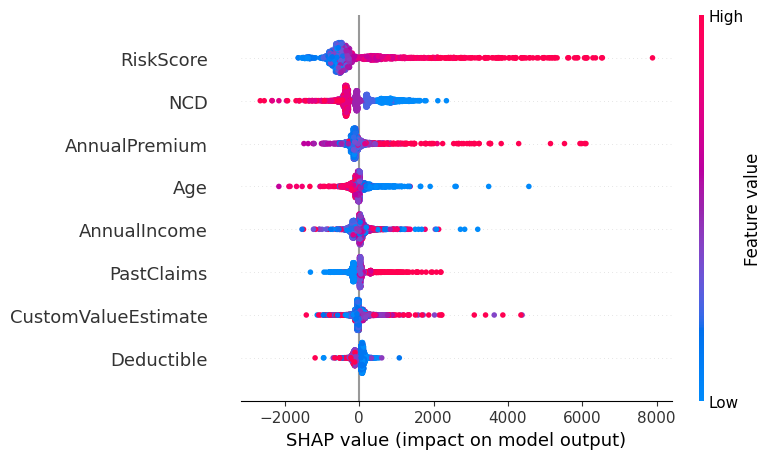

In [25]:
import shap

explainer = shap.Explainer(xgb)

shap_values = explainer(X_test)

shap.summary_plot(
    shap_values,
    X_test
)

The SHAP analysis demonstrates that the XGBoost model successfully identifies the major drivers of insurance risk. Behavioral and historical risk indicators such as RiskScore, NCD, and PastClaims are more influential than basic demographic variables. This supports the development of a dynamic, risk-based pricing framework that improves profitability while enabling competitive pricing for low-risk customers.

Premium=P(claim)×Predicted Severity+Expense Loading + profit Margin